# <span style="color:darkcyan"> Lecture 5 </span>
## <span style="color:darkgreen">  Metropolis algorithm & Hydrogen atom </span>


In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.gridspec as gridspec
plt.style.use('default')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

### Uniform

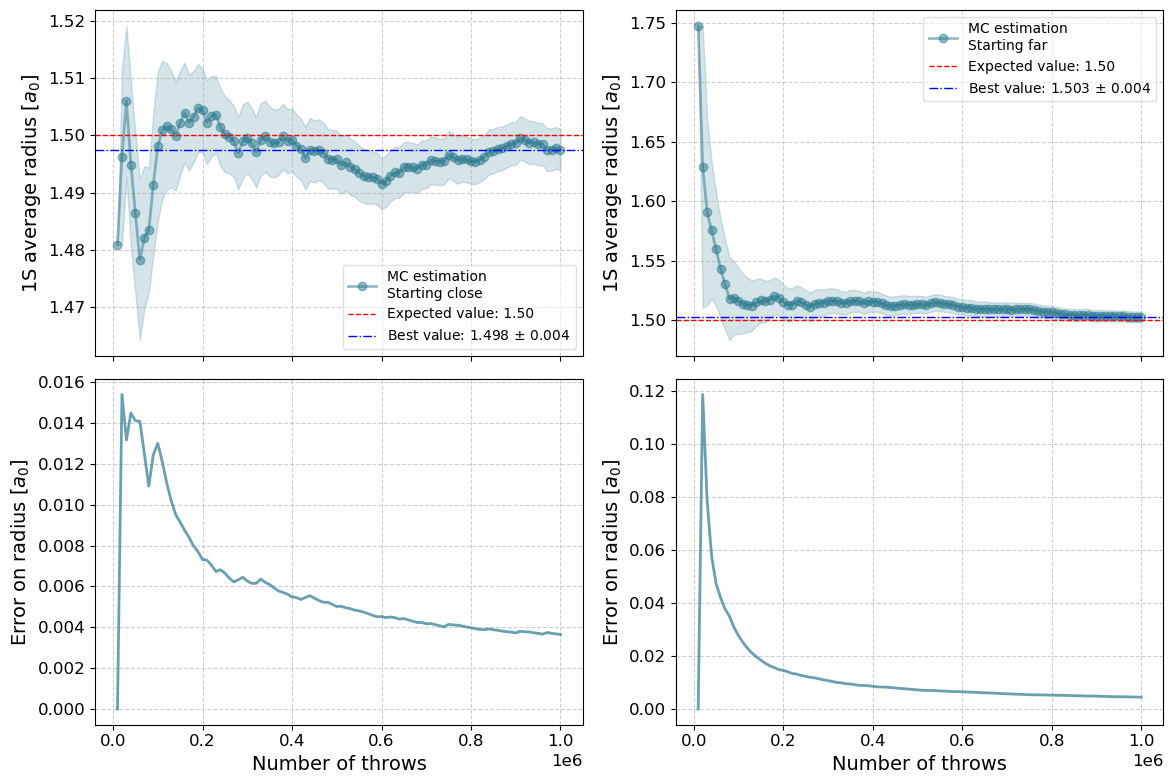

In [30]:
file_1s = "output_average_1s_uniform.data"
file_1s_far = "output_average_1s_far_uniform.data"
x_1s, y_1s, error_1s = np.loadtxt(file_1s, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_1s_far, y_1s_far, error_1s_far = np.loadtxt(file_1s_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor('white')  

viridis = plt.cm.viridis
color_1s = viridis(0.4)
ref_color = 'red'
ref_color_2 = 'blue'

expected_val = 1.5
best_val_near = y_1s[99]
best_val_far = y_1s_far[99]

# Plot 1S - Near
ax[0, 0].plot(x_1s, y_1s, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_1s, y_1s+error_1s,y_1s-error_1s, color=color_1s, alpha=0.2)
ax[0, 0].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(
    y=best_val_near,
    color=ref_color_2,
    linestyle='-.',
    linewidth=1,
    label=rf'Best value: {best_val_near:.3f} $\pm$ {error_1s[99]:.3f}'
)
ax[0, 0].set_ylabel('1S average radius [$a_0$]')
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Plot 1S - Far
ax[0, 1].plot(x_1s_far, y_1s_far, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_1s_far, y_1s_far+error_1s_far,y_1s_far-error_1s_far, color=color_1s, alpha=0.2)
ax[0, 1].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=best_val_far, color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {best_val_far:.3f} $\pm$ {error_1s_far[99]:.3f}'
)
ax[0, 1].set_ylabel('1S average radius [$a_0$]')
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Errori
ax[1, 0].plot(x_1s, error_1s, '-', color=color_1s, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_1s_far, error_1s_far, '-', color=color_1s, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


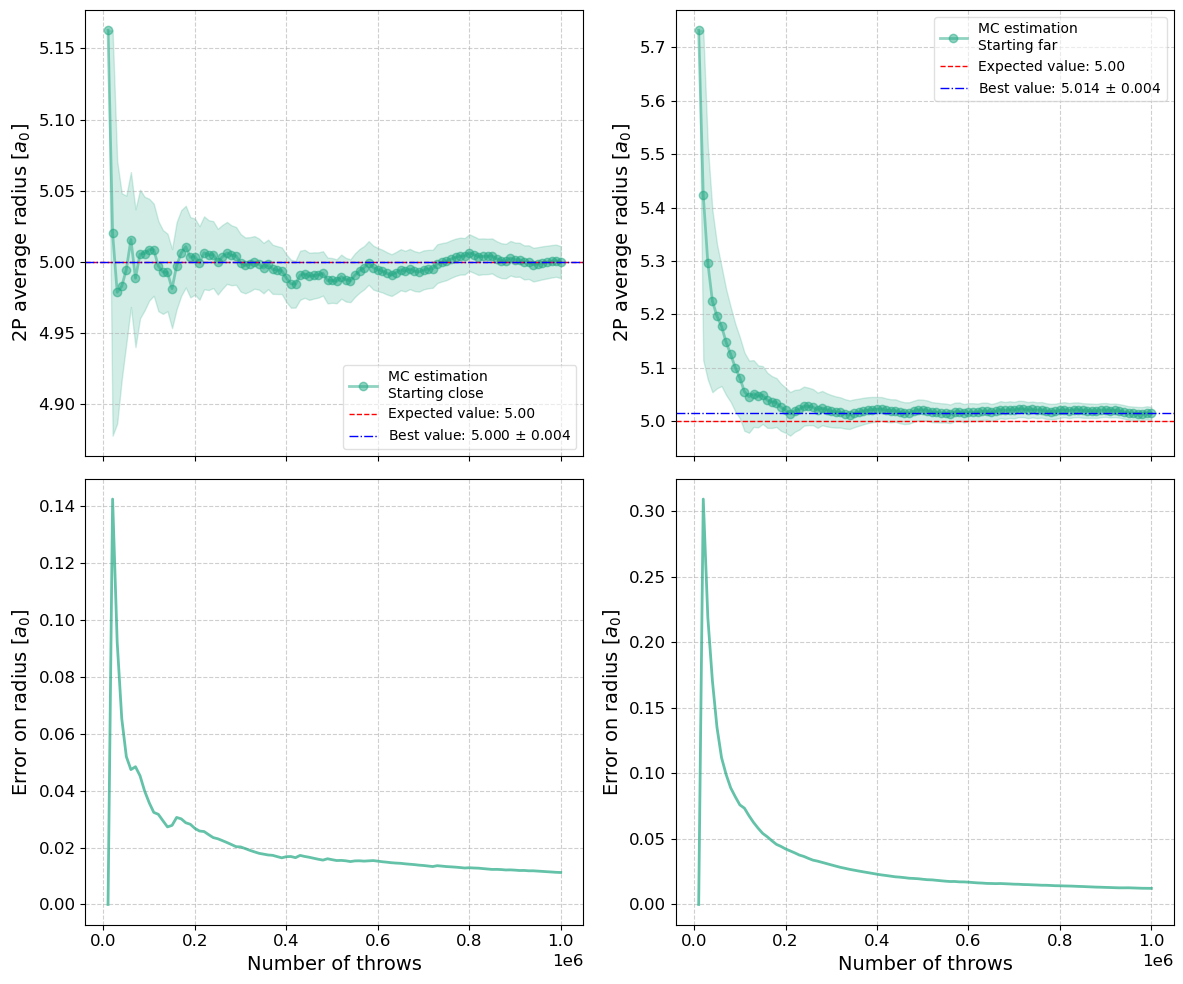

In [31]:
file_2p = "output_average_2p_uniform.data"
file_2p_far = "output_average_2p_far_uniform.data"
x_2p, y_2p, error_2p = np.loadtxt(file_2p, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_2p_far, y_2p_far, error_2p_far = np.loadtxt(file_2p_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor('white')  

viridis = plt.cm.viridis
color_2p = viridis(0.6)
ref_color = 'red'
ref_color_2 = 'blue'

expected_val = 5.
best_val_near = y_2p[99]
best_val_far = y_2p_far[99]

# Plot 2P - Near

ax[0, 0].plot(x_2p, y_2p, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_2p, y_2p+error_2p,y_2p-error_2p, color=color_2p, alpha=0.2)
ax[0, 0].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 0].axhline(
    y=best_val_near,
    color=ref_color_2,
    linestyle='-.',
    linewidth=1,
    label=rf'Best value: {best_val_near:.3f} $\pm$ {error_1s[99]:.3f}')
ax[0, 0].set_ylabel('2P average radius [$a_0$]')
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Plot 2P - Far
ax[0, 1].plot(x_2p_far, y_2p_far, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_2p_far, y_2p_far+error_2p_far,y_2p_far-error_2p_far, color=color_2p, alpha=0.2)
ax[0, 1].axhline(y=expected_val, color=ref_color, linestyle='--', linewidth=1,
                 label=f'Expected value: {expected_val:.2f}')
ax[0, 1].axhline(y=best_val_far, color=ref_color_2, linestyle='-.', linewidth=1,
                     label=rf'Best value: {best_val_far:.3f} $\pm$ {error_1s_far[99]:.3f}')
ax[0, 1].set_ylabel('2P average radius [$a_0$]')
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].legend(loc='upper right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6, fontsize='small')

# Errori
ax[1, 0].plot(x_2p, error_2p, '-', color=color_2p, alpha=0.7)
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('Error on radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)

ax[1, 1].plot(x_2p_far, error_2p_far, '-', color=color_2p, alpha=0.7)
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('Error on radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


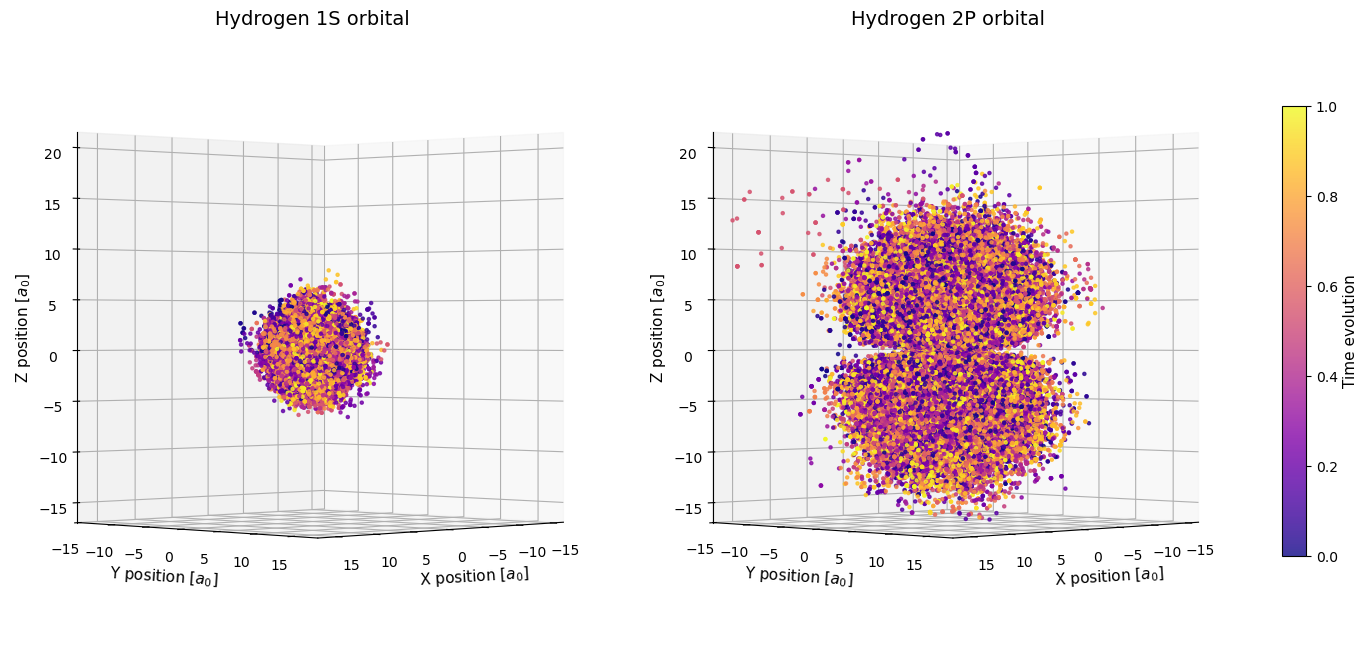

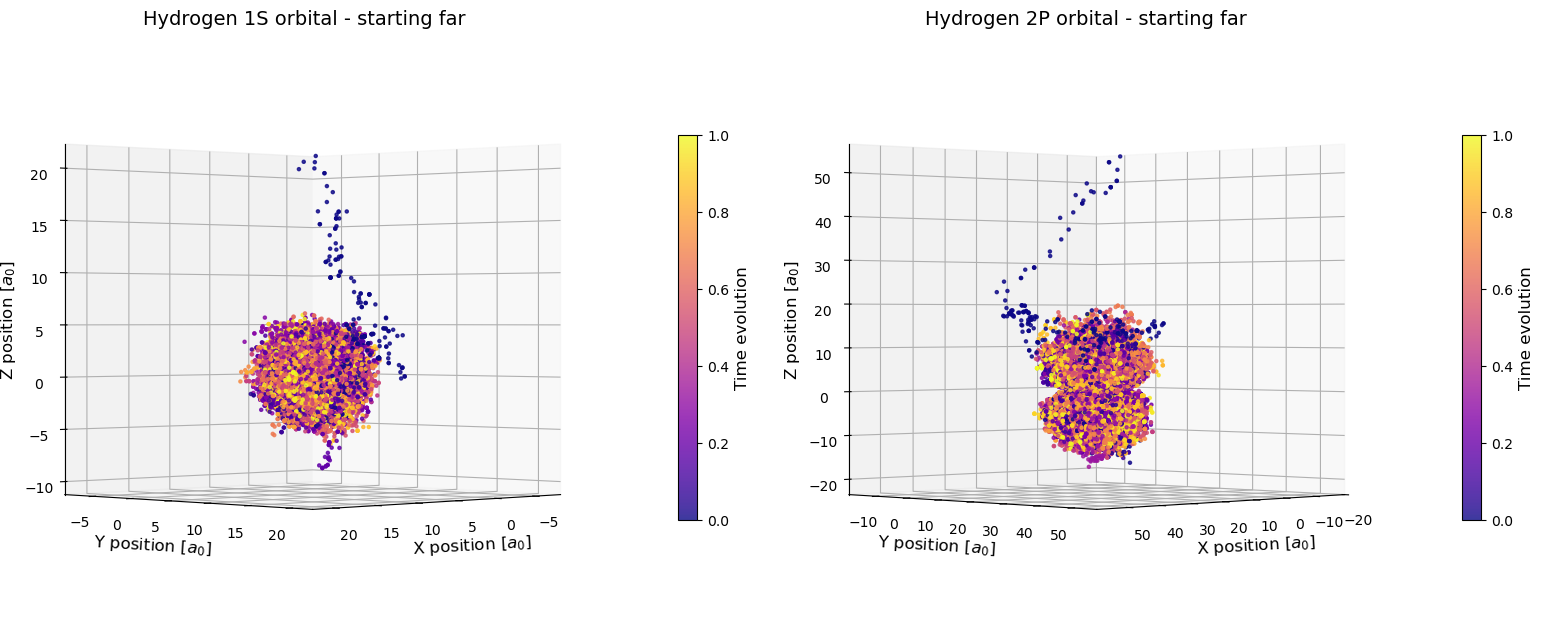

In [ ]:
data_1s = np.loadtxt("positions_1s_uniform.data")
data_2p = np.loadtxt("positions_2p_uniform.data")

all_data = np.vstack((data_1s, data_2p))
x_min, x_max = all_data[:, 0].min(), all_data[:, 0].max()
y_min, y_max = all_data[:, 1].min(), all_data[:, 1].max()
z_min, z_max = all_data[:, 2].min(), all_data[:, 2].max()

def set_equal_limits_and_aspect(ax):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect([x_max - x_min, y_max - y_min, z_max - z_min])

plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

cmap = "plasma"
colors_1s = np.linspace(0, 1, len(data_1s))
colors_2p = np.linspace(0, 1, len(data_2p))

ax1 = fig.add_subplot(gs[0], projection='3d')
sc1 = ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2],
                  c=colors_1s, cmap=cmap, s=5, alpha=0.8)
ax1.set_title("Hydrogen 1S orbital", fontsize=14, color='black')
ax1.set_xlabel("X position [$a_0$]", fontsize=11)
ax1.set_ylabel("Y position [$a_0$]", fontsize=11)
ax1.set_zlabel("Z position [$a_0$]", fontsize=11)
ax1.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax1)

ax2 = fig.add_subplot(gs[1], projection='3d')
sc2 = ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2],
                  c=colors_2p, cmap=cmap, s=5, alpha=0.8)
ax2.set_title("Hydrogen 2P orbital", fontsize=14, color='black')
ax2.set_xlabel("X position [$a_0$]", fontsize=11)
ax2.set_ylabel("Y position [$a_0$]", fontsize=11)
ax2.set_zlabel("Z position [$a_0$]", fontsize=11)
ax2.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax2)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time evolution", fontsize=11)

plt.subplots_adjust(wspace=0.05, right=0.9)
plt.show()

# Starting far
#==============================================================================
data_1s_far = np.loadtxt("positions_1s_far_uniform.data")
data_2p_far = np.loadtxt("positions_2p_far_uniform.data")

fig2 = plt.figure(figsize=(16, 8))
ax3 = fig2.add_subplot(121, projection='3d')
colors_1s_far = np.linspace(0, 1, len(data_1s_far))
sc3 = ax3.scatter(data_1s_far[:, 0], data_1s_far[:, 1], data_1s_far[:, 2], 
                  c=colors_1s_far, cmap="plasma", s=5, alpha=0.8)

ax3.set_box_aspect((1, 1, 1)) 
cbar3 = fig2.colorbar(sc3, ax=ax3, shrink=0.5, pad=0.1)
cbar3.set_label("Time evolution", fontsize=12)

ax3.set_xlabel("X position [$a_0$]", fontsize=12)
ax3.set_ylabel("Y position [$a_0$]", fontsize=12)
ax3.set_zlabel("Z position [$a_0$]", fontsize=12)
ax3.set_title("Hydrogen 1S orbital - starting far", fontsize=14)
ax3.view_init(elev=0, azim=45)

ax4 = fig2.add_subplot(122, projection='3d')
colors_2p_far = np.linspace(0, 1, len(data_2p_far))
sc4 = ax4.scatter(data_2p_far[:, 0], data_2p_far[:, 1], data_2p_far[:, 2], 
                  c=colors_2p_far, cmap="plasma", s=5, alpha=0.8)

ax4.set_box_aspect((1, 1, 1))
cbar4 = fig2.colorbar(sc4, ax=ax4, shrink=0.5, pad=0.1)
cbar4.set_label("Time evolution", fontsize=12)

ax4.set_xlabel("X position [$a_0$]", fontsize=12)
ax4.set_ylabel("Y position [$a_0$]", fontsize=12)
ax4.set_zlabel("Z position [$a_0$]", fontsize=12)
ax4.set_title("Hydrogen 2P orbital - starting far ", fontsize=14)
ax4.view_init(elev=0, azim=45)

plt.tight_layout()
plt.show()


### Gaussian

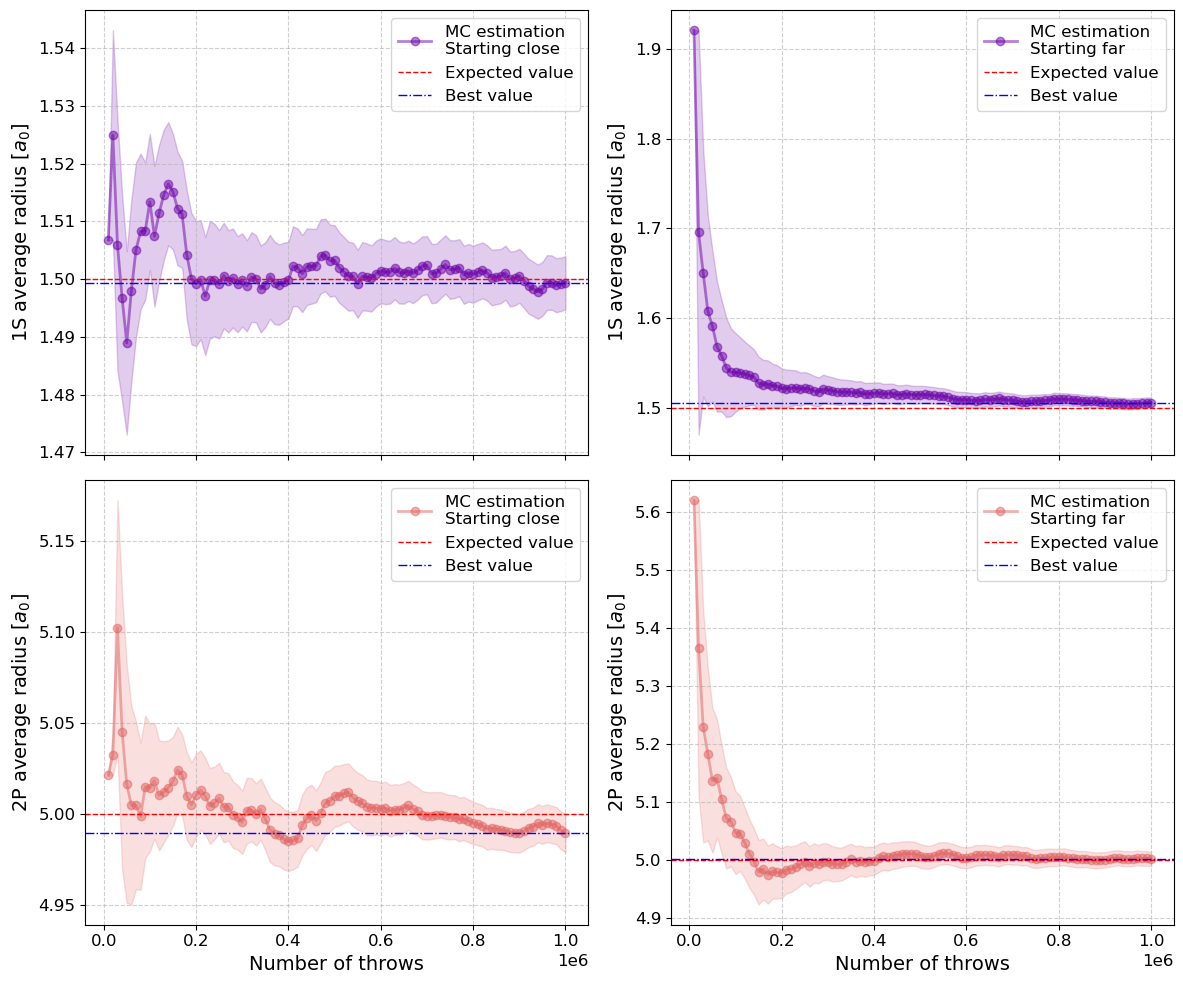

In [36]:
file_1s = "output_average_1s_gauss.data"
file_1s_far = "output_average_1s_far_gauss.data"
x_1s, y_1s, error_1s = np.loadtxt(file_1s, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_1s_far, y_1s_far, error_1s_far = np.loadtxt(file_1s_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

plasma = plt.cm.plasma
color_1s = plasma(0.2)
ref_color = 'red'
ref_color_2 = 'blue'

# 1S - Near
ax[0, 0].plot(x_1s, y_1s, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting close')
ax[0, 0].fill_between(x_1s, y_1s+error_1s,y_1s-error_1s, color=color_1s, alpha=0.2)
ax[0, 0].axhline(y=1.5, color=ref_color, linestyle='--', linewidth=1, label='Expected value')
ax[0, 0].axhline(y=y_1s[99], color=ref_color_2, linestyle='-.', linewidth=1, label='Best value')
ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 0].set_ylabel('1S average radius [$a_0$]')
ax[0, 0].grid(True, linestyle='--', alpha=0.6)
ax[0, 0].legend()

# 1S - Far
ax[0, 1].plot(x_1s_far, y_1s_far, marker='o', color=color_1s, alpha=0.5, label='MC estimation \nStarting far')
ax[0, 1].fill_between(x_1s_far, y_1s_far+error_1s_far,y_1s_far-error_1s_far, color=color_1s, alpha=0.2)
ax[0, 1].axhline(y=1.5, color=ref_color, linestyle='--', linewidth=1, label='Expected value')
ax[0, 1].axhline(y=y_1s_far[99], color=ref_color_2, linestyle='-.', linewidth=1, label='Best value')
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[0, 1].set_ylabel('1S average radius [$a_0$]')
ax[0, 1].grid(True, linestyle='--', alpha=0.6)
ax[0, 1].legend()


file_2p = "output_average_2p_gauss.data"
file_2p_far = "output_average_2p_far_gauss.data"
x_2p, y_2p, error_2p = np.loadtxt(file_2p, usecols=(0, 1, 2), delimiter='\t', unpack=True)
x_2p_far, y_2p_far, error_2p_far = np.loadtxt(file_2p_far, usecols=(0, 1, 2), delimiter='\t', unpack=True)

color_2p = plasma(0.6)

# 2P - Near
ax[1, 0].plot(x_2p, y_2p, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting close')
ax[1, 0].fill_between(x_2p, y_2p+error_2p,y_2p-error_2p, color=color_2p, alpha=0.2)
ax[1, 0].axhline(y=5.0, color=ref_color, linestyle='--', linewidth=1, label='Expected value')
ax[1, 0].axhline(y=y_2p[99], color=ref_color_2, linestyle='-.', linewidth=1, label='Best value')
ax[1, 0].set_xlabel('Number of throws')
ax[1, 0].set_ylabel('2P average radius [$a_0$]')
ax[1, 0].grid(True, linestyle='--', alpha=0.6)
ax[1, 0].legend()

# 2P - Far
ax[1, 1].plot(x_2p_far, y_2p_far, marker='o', color=color_2p, alpha=0.5, label='MC estimation \nStarting far')
ax[1, 1].fill_between(x_2p_far, y_2p_far+error_2p_far,y_2p_far-error_2p_far, color=color_2p, alpha=0.2)
ax[1, 1].axhline(y=5.0, color=ref_color, linestyle='--', linewidth=1, label='Expected value')
ax[1, 1].axhline(y=y_2p_far[99], color=ref_color_2, linestyle='-.', linewidth=1, label='Best value')
ax[1, 1].set_xlabel('Number of throws')
ax[1, 1].set_ylabel('2P average radius [$a_0$]')
ax[1, 1].grid(True, linestyle='--', alpha=0.6)
ax[1, 1].legend()

plt.tight_layout()
plt.show()


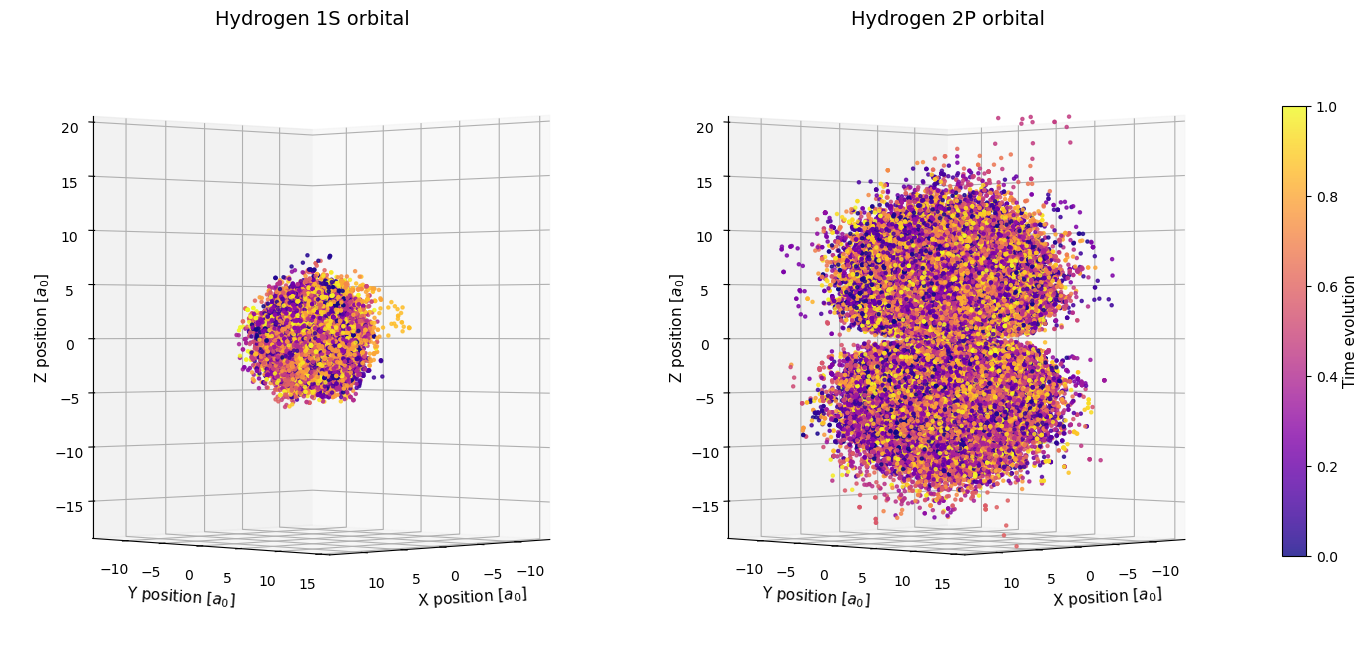

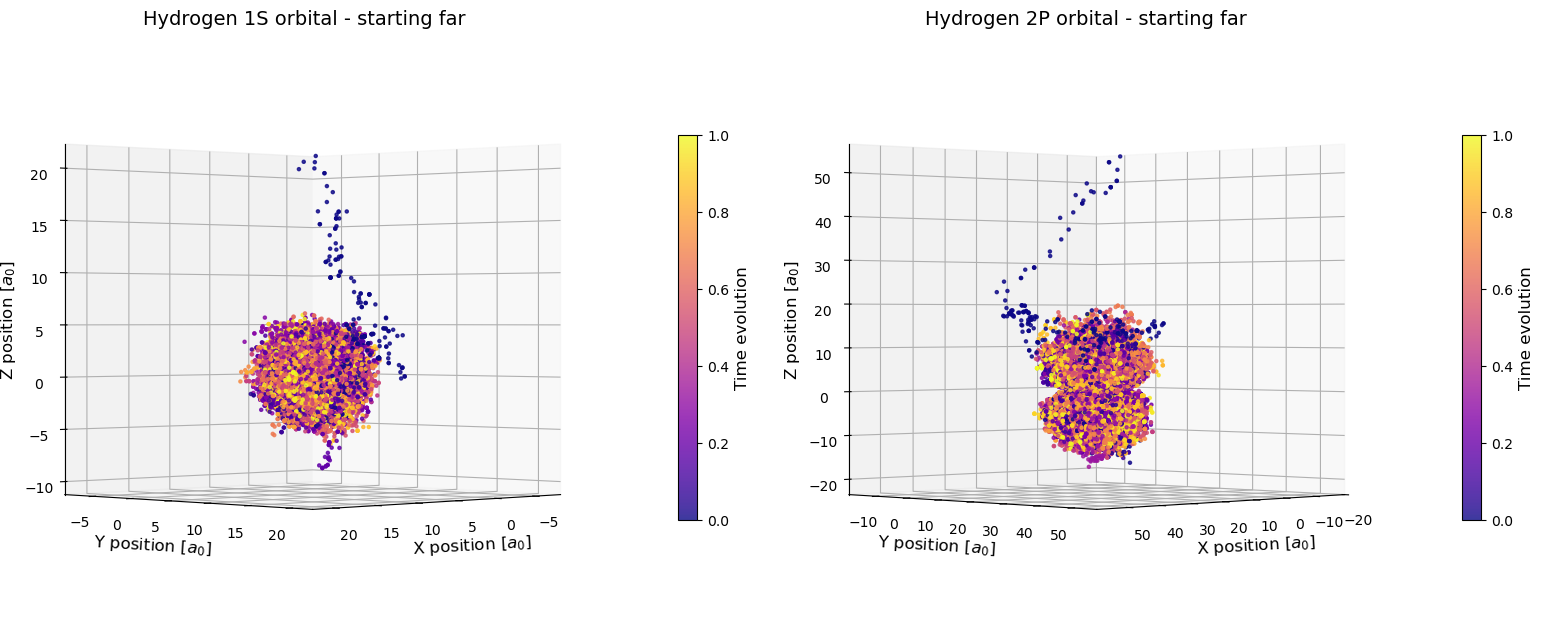

In [ ]:
data_1s = np.loadtxt("positions_1s_gauss.data")
data_2p = np.loadtxt("positions_2p_gauss.data")

all_data = np.vstack((data_1s, data_2p))
x_min, x_max = all_data[:, 0].min(), all_data[:, 0].max()
y_min, y_max = all_data[:, 1].min(), all_data[:, 1].max()
z_min, z_max = all_data[:, 2].min(), all_data[:, 2].max()

def set_equal_limits_and_aspect(ax):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect([x_max - x_min, y_max - y_min, z_max - z_min])

plt.style.use('default')
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

cmap = "plasma"
colors_1s = np.linspace(0, 1, len(data_1s))
colors_2p = np.linspace(0, 1, len(data_2p))

ax1 = fig.add_subplot(gs[0], projection='3d')
sc1 = ax1.scatter(data_1s[:, 0], data_1s[:, 1], data_1s[:, 2],
                  c=colors_1s, cmap=cmap, s=5, alpha=0.8)
ax1.set_title("Hydrogen 1S orbital", fontsize=14, color='black')
ax1.set_xlabel("X position [$a_0$]", fontsize=11)
ax1.set_ylabel("Y position [$a_0$]", fontsize=11)
ax1.set_zlabel("Z position [$a_0$]", fontsize=11)
ax1.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax1)

ax2 = fig.add_subplot(gs[1], projection='3d')
sc2 = ax2.scatter(data_2p[:, 0], data_2p[:, 1], data_2p[:, 2],
                  c=colors_2p, cmap=cmap, s=5, alpha=0.8)
ax2.set_title("Hydrogen 2P orbital", fontsize=14, color='black')
ax2.set_xlabel("X position [$a_0$]", fontsize=11)
ax2.set_ylabel("Y position [$a_0$]", fontsize=11)
ax2.set_zlabel("Z position [$a_0$]", fontsize=11)
ax2.view_init(elev=0, azim=45)
set_equal_limits_and_aspect(ax2)

cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
cbar = fig.colorbar(sc2, cax=cbar_ax)
cbar.set_label("Time evolution", fontsize=11)

plt.subplots_adjust(wspace=0.05, right=0.9)
plt.show()

# Starting far
#==============================================================================
data_1s_far = np.loadtxt("positions_1s_far_uniform.data")
data_2p_far = np.loadtxt("positions_2p_far_uniform.data")

fig2 = plt.figure(figsize=(16, 8))
ax3 = fig2.add_subplot(121, projection='3d')
colors_1s_far = np.linspace(0, 1, len(data_1s_far))
sc3 = ax3.scatter(data_1s_far[:, 0], data_1s_far[:, 1], data_1s_far[:, 2], 
                  c=colors_1s_far, cmap="plasma", s=5, alpha=0.8)

ax3.set_box_aspect((1, 1, 1)) 
cbar3 = fig2.colorbar(sc3, ax=ax3, shrink=0.5, pad=0.1)
cbar3.set_label("Time evolution", fontsize=12)

ax3.set_xlabel("X position [$a_0$]", fontsize=12)
ax3.set_ylabel("Y position [$a_0$]", fontsize=12)
ax3.set_zlabel("Z position [$a_0$]", fontsize=12)
ax3.set_title("Hydrogen 1S orbital - starting far", fontsize=14)
ax3.view_init(elev=0, azim=45)

ax4 = fig2.add_subplot(122, projection='3d')
colors_2p_far = np.linspace(0, 1, len(data_2p_far))
sc4 = ax4.scatter(data_2p_far[:, 0], data_2p_far[:, 1], data_2p_far[:, 2], 
                  c=colors_2p_far, cmap="plasma", s=5, alpha=0.8)
ax4.set_box_aspect((1, 1, 1))

cbar4 = fig2.colorbar(sc4, ax=ax4, shrink=0.5, pad=0.1)
cbar4.set_label("Time evolution", fontsize=12)

ax4.set_xlabel("X position [$a_0$]", fontsize=12)
ax4.set_ylabel("Y position [$a_0$]", fontsize=12)
ax4.set_zlabel("Z position [$a_0$]", fontsize=12)
ax4.set_title("Hydrogen 2P orbital - starting far ", fontsize=14)
ax4.view_init(elev=0, azim=45)

plt.tight_layout()
plt.show()
